In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
 accuracy_score,
 confusion_matrix,
 classification_report,
 roc_auc_score,
 log_loss,
 RocCurveDisplay,
 ConfusionMatrixDisplay
)

In [8]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
car_evaluation = fetch_ucirepo(id=19) 

# data (as pandas dataframes) 
X = car_evaluation.data.features 
y = car_evaluation.data.targets["class"]

y = y.map({
    "unacc": 0,
    "acc": 1,
    "good": 1,
    "vgood": 1
})

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
# One-hot encode features
encoder = OneHotEncoder(handle_unknown="ignore")

X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)

In [11]:
# Train Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)

Accuracy: 0.9566473988439307


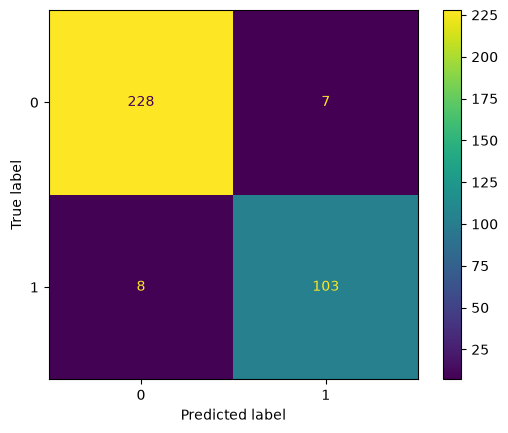

In [12]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()